In [1]:
import pandas as pd
import numpy as np
import tkinter
import matplotlib
import os
from matplotlib.backends.backend_tkagg import *

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from helpers.select_scenario import select_scenario
from helpers.load import *

scenario_folder = select_scenario()

Select a scenario:
[0]: lake
[1]: soil
Selected scenario: lake

Select a test run:
[0]: 2025-03-01_07:30
[1]: 2025-03-01_07:31
[2]: 2025-03-01_07:32
Selected run: 2025-03-01_07:31


In [2]:
def node_to_node_distance(x1,y1,z1,x2,y2,z2):
    return ((x1-x2)**2 + (y1-y2)**2 + (z1-z2)**2)**0.5

node_pos_df = load_node_pos_df(scenario_folder)
node_pos_df

,Time,NodeType,NodeId,X,Y,Z
0,0.0,STA,0,1,1,-40
1,0.0,STA,1,3,1,-40
2,0.0,STA,2,5,1,-40
3,0.0,STA,3,7,1,-40
4,0.0,STA,4,9,1,-40
5,0.0,STA,5,11,1,-40
6,0.0,STA,6,13,1,-40
7,0.0,STA,7,15,1,-40
8,0.0,STA,8,17,1,-40
9,0.0,STA,9,19,1,-40


In [22]:
rx_drop_packets_df = load_phy_rx_drop(scenario_folder)
tx_drop_packets_df = load_phy_tx_drop(scenario_folder)

# Get the list of PacketIds dropped during receiving
dropped_packets_rx = rx_drop_packets_df.groupby("ReceiverNodeId").size().reset_index(name="DroppedPacketsSum")
#dropped_packets_rx.rename(columns={"ReceiverNodeId" : "NodeId"}, inplace = True)
#dropped_packets_rx.set_index("NodeId", inplace=True)

# Get the list of PacketIds dropped during transmission, but this is empty
dropped_packets_tx = tx_drop_packets_df.groupby("TransmitterNodeId").size().reset_index(name="DroppedPacketsSum")
dropped_packets_tx = dropped_packets_tx.rename(columns={"TransmitterNodeId" : "NodeId"}, inplace = True)

# Merge them together
#dropped_packets_sum = pd.merge(dropped_packets_rx, dropped_packets_tx, on= "NodeId", how="outer")
dropped_packets_rx

,ReceiverNodeId,DroppedPacketsSum
0,0,2
1,5,1
2,18,5
3,20,1
4,37,1
5,40,1
6,44,2
7,46,1
8,50,279


In [9]:
rx_end_packets_df = load_phy_rx_end(scenario_folder)
rx_end_packets_df = rx_end_packets_df[rx_end_packets_df["ReceiverNodeId"] == rx_end_packets_df["DestinationNodeId"]]

# For latency, we want to focus on the first reception of the particular packet
rx_end_packets_df = rx_end_packets_df.sort_values(by="Time")
rx_end_packets_df = rx_end_packets_df.groupby(["PacketId", "SourceNodeId"]).first().reset_index()

rx_end_packets_df
#rx_end_packets_df.loc[(rx_end_packets_df["SourceNodeId"]==1) & (rx_end_packets_df["PacketId"]==6)]

,PacketId,SourceNodeId,Time,SnifferNodeId,PacketSize,ReceiverMac,ReceiverNodeId,TransmitterMac,TransmitterNodeId,BSSID,BSSIDNodeId,DestinationMac,DestinationNodeId,SourceMac,IsRetry
0,5,44,5.734395e+08,50,102,00:00:00:00:00:33,50,00:00:00:00:00:2d,44,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:2d,True
1,6,35,5.396209e+08,50,102,00:00:00:00:00:33,50,00:00:00:00:00:24,35,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:24,True
2,7,26,5.122111e+08,50,102,00:00:00:00:00:33,50,00:00:00:00:00:1b,26,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:1b,True
3,8,38,5.706291e+08,50,102,00:00:00:00:00:33,50,00:00:00:00:00:27,38,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:27,True
4,9,12,5.454498e+08,50,102,00:00:00:00:00:33,50,00:00:00:00:00:0d,12,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:0d,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,28470,50,2.822765e+12,47,90,00:00:00:00:00:30,47,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:30,47,00:00:00:00:00:33,False
391,29060,48,2.882590e+12,50,103,00:00:00:00:00:33,50,00:00:00:00:00:31,48,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:31,False
392,29061,50,2.882772e+12,48,90,00:00:00:00:00:31,48,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:31,48,00:00:00:00:00:33,False
393,29650,49,2.942566e+12,50,103,00:00:00:00:00:33,50,00:00:00:00:00:32,49,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:32,False


In [10]:
tx_begin_packets_df = load_phy_tx_begin(scenario_folder)
#tx_begin_packets_df["PacketId"] = tx_begin_packets_df["PacketId"].astype(int)
tx_begin_packets_df = tx_begin_packets_df[tx_begin_packets_df["TransmitterNodeId"] == tx_begin_packets_df["SourceNodeId"]]

# For latency, we want to focus on the first transmission of this particular packet
tx_begin_packets_df = tx_begin_packets_df.sort_values(by="Time")
tx_begin_packets_df = tx_begin_packets_df.groupby(["PacketId", "SourceNodeId"]).first().reset_index()
#tx_begin_packets_df = tx_begin_packets_df.drop_duplicates()
#tx_begin_packets_df = tx_begin_packets_df[~tx_begin_packets_df["PacketId"].isin(dropped_packets)]
#tx_begin_packets_df.loc[(tx_begin_packets_df["SourceNodeId"]==1) & (tx_begin_packets_df["PacketId"]==6)]
tx_begin_packets_df

,PacketId,SourceNodeId,Time,SnifferNodeId,PacketSize,ReceiverMac,ReceiverNodeId,TransmitterMac,TransmitterNodeId,BSSID,BSSIDNodeId,DestinationMac,DestinationNodeId,SourceMac,IsRetry
0,5,44,5.027332e+08,44,102,00:00:00:00:00:33,50,00:00:00:00:00:2d,44,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:2d,False
1,6,35,5.027332e+08,35,102,00:00:00:00:00:33,50,00:00:00:00:00:24,35,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:24,False
2,7,26,5.027332e+08,26,102,00:00:00:00:00:33,50,00:00:00:00:00:1b,26,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:1b,False
3,8,38,5.027332e+08,38,102,00:00:00:00:00:33,50,00:00:00:00:00:27,38,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:27,False
4,9,12,5.027332e+08,12,102,00:00:00:00:00:33,50,00:00:00:00:00:0d,12,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:0d,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,28470,50,2.822764e+12,50,90,00:00:00:00:00:30,47,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:30,47,00:00:00:00:00:33,False
391,29060,48,2.882588e+12,48,103,00:00:00:00:00:33,50,00:00:00:00:00:31,48,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:31,False
392,29061,50,2.882770e+12,50,90,00:00:00:00:00:31,48,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:31,48,00:00:00:00:00:33,False
393,29650,49,2.942565e+12,49,103,00:00:00:00:00:33,50,00:00:00:00:00:32,49,00:00:00:00:00:33,50,00:00:00:00:00:33,50,00:00:00:00:00:32,False


In [ ]:
packet_stats_df = pd.DataFrame()
packet_stats_df['Sent packet count'] = tx_begin_packets_df['PacketId'].value_counts()
packet_stats_df['Received packet count'] = rx_end_packets_df['PacketId'].value_counts()

packet_stats_df['First seen at'] = tx_begin_packets_df.groupby('PacketId')['Time'].min()
packet_stats_df['Received at'] = rx_end_packets_df.groupby('PacketId')['Time'].max()
packet_stats_df['Latency'] = packet_stats_df['Received at'] - packet_stats_df['First seen at']
packet_stats_df['SourceNodeId'] = tx_begin_packets_df.groupby('PacketId')['SourceNodeId'].first()
packet_stats_df['DestinationNodeId'] = tx_begin_packets_df.groupby('PacketId')['DestinationNodeId'].first()

# Calculate the distance between the two nodes at the time of the most recent position update at the time of the first packet transmission
packet_stats_df['Distance'] = packet_stats_df.apply(lambda row: node_to_node_distance(
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['NodeId'] == row['SourceNodeId'])].iloc[-1]['X'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['NodeId'] == row['SourceNodeId'])].iloc[-1]['Y'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['NodeId'] == row['SourceNodeId'])].iloc[-1]['Z'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['NodeId'] == row['DestinationNodeId'])].iloc[-1]['X'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['NodeId'] == row['DestinationNodeId'])].iloc[-1]['Y'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['NodeId'] == row['DestinationNodeId'])].iloc[-1]['Z'],
), axis=1)

packet_stats_df.sort_values("Sent packet count", ascending=False).head(50)

,Sent packet count,Received packet count,First seen at,Received at,Latency,SourceNodeId,DestinationNodeId,Distance
PacketId,,,,,,,,
5,1,1,5.027332e+08,5.734395e+08,70706302.0,44,50,40.024992
39,1,1,5.751755e+08,5.793027e+08,4127223.0,50,5,41.012193
8,1,1,5.027332e+08,5.706291e+08,67895894.0,38,50,40.718546
9,1,1,5.027332e+08,5.454498e+08,42716587.0,12,50,40.914545
10,1,1,5.027332e+08,5.284612e+08,25728026.0,21,50,40.914545
11,1,1,5.027332e+08,5.426914e+08,39958144.0,5,50,41.012193
12,1,1,5.027332e+08,5.940622e+08,91328981.0,40,50,41.012193
13,1,1,5.027332e+08,5.534269e+08,50693715.0,3,50,41.109610
14,1,1,5.027332e+08,5.652105e+08,62477292.0,30,50,41.109610


In [19]:
node_statistics_df = pd.DataFrame()
node_statistics_df['NodeId'] = node_pos_df['NodeId'].unique()
node_statistics_df.set_index('NodeId', inplace=True)
node_statistics_df['NodeType'] = node_pos_df.groupby('NodeId')['NodeType'].first()
node_statistics_df['X'] = node_pos_df.groupby('NodeId')['X'].last()
node_statistics_df['Y'] = node_pos_df.groupby('NodeId')['Y'].last()
node_statistics_df['Z'] = node_pos_df.groupby('NodeId')['Z'].last()
node_statistics_df['Sent packet count'] = packet_stats_df.groupby('SourceNodeId')['Sent packet count'].sum()
node_statistics_df['Received packet count'] = packet_stats_df.groupby('DestinationNodeId')['Received packet count'].sum()
node_statistics_df = node_statistics_df.merge(dropped_packets_rx[["DroppedPacketsSum"]], on="NodeId", how="left")
node_statistics_df["DroppedPacketsSum"].fillna(0, inplace=True)
node_statistics_df.rename(columns={"DroppedPacketsSum": "Dropped Packets count"})
node_statistics_df['Average latency'] = packet_stats_df.groupby('SourceNodeId')['Latency'].mean()
#node_statistics_df['Average signal strength'] = rx_end_packets_df.groupby('DestinationNodeId')['SignalDbm'].mean()
node_statistics_df

,NodeType,X,Y,Z,Sent packet count,Received packet count,DroppedPacketsSum,Average latency
NodeId,,,,,,,,
0,STA,1,1,-40,5,4,2.0,5.482426e+07
1,STA,3,1,-40,5,3,0.0,8.560104e+07
2,STA,5,1,-40,5,3,0.0,3.572916e+07
3,STA,7,1,-40,5,3,0.0,3.627500e+07
4,STA,9,1,-40,4,3,0.0,5.348993e+07
5,STA,11,1,-40,4,3,1.0,7.065014e+07
6,STA,13,1,-40,5,3,0.0,8.695491e+07
7,STA,15,1,-40,5,3,0.0,2.826737e+07
8,STA,17,1,-40,4,3,0.0,4.694848e+07


In [ ]:
# Merge packet_stats_df with rx_packets_df based on PacketId
merged_df = pd.merge(packet_stats_df, rx_end_packets_df, on='PacketId', how='inner')

%matplotlib inline
# Plot signal loss over distance and time
#fig, ax = plt.subplots(1, 2, figsize=(15,5))
#ax[0].scatter(merged_df['Distance'], merged_df['SignalDbm'], alpha=0.5)
#ax[0].set_xlabel('Distance (m)')
#ax[0].set_ylabel('Signal loss (dB)')
#ax[1].scatter(merged_df['Time'], merged_df['SignalDbm'], alpha=0.5)
#ax[1].set_xlabel('Time (ns)')
#ax[1].set_ylabel('Signal loss (dB)')
#plt.show()

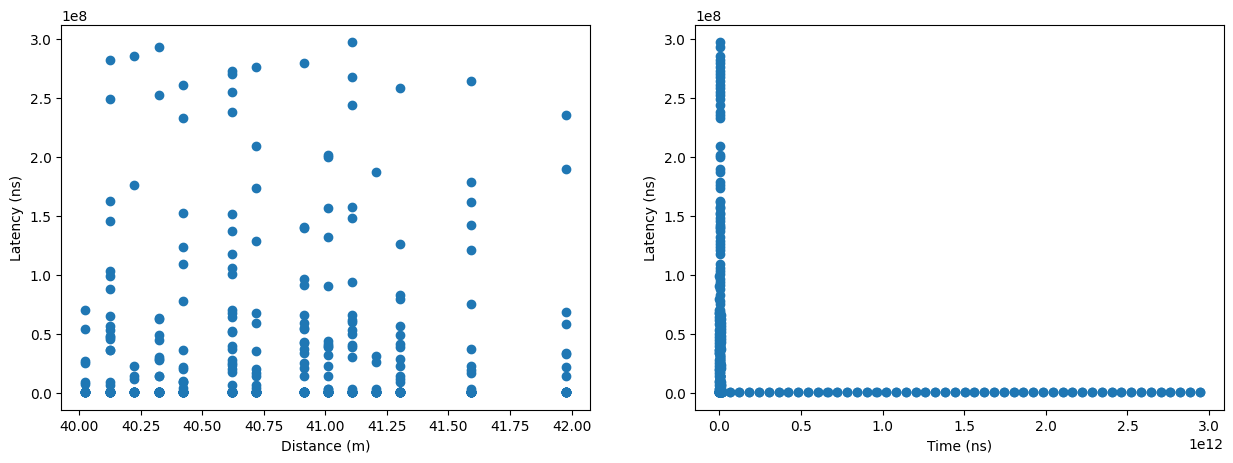

In [20]:
%matplotlib inline
# Plot latency over distance in one plot, and over time in another
fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].scatter(packet_stats_df['Distance'], packet_stats_df['Latency'])
ax[0].set_xlabel('Distance (m)')
ax[0].set_ylabel('Latency (ns)')
ax[1].scatter(packet_stats_df['First seen at'], packet_stats_df['Latency'])
ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel('Latency (ns)')
plt.show()

KeyError: 'Dropped packet count'

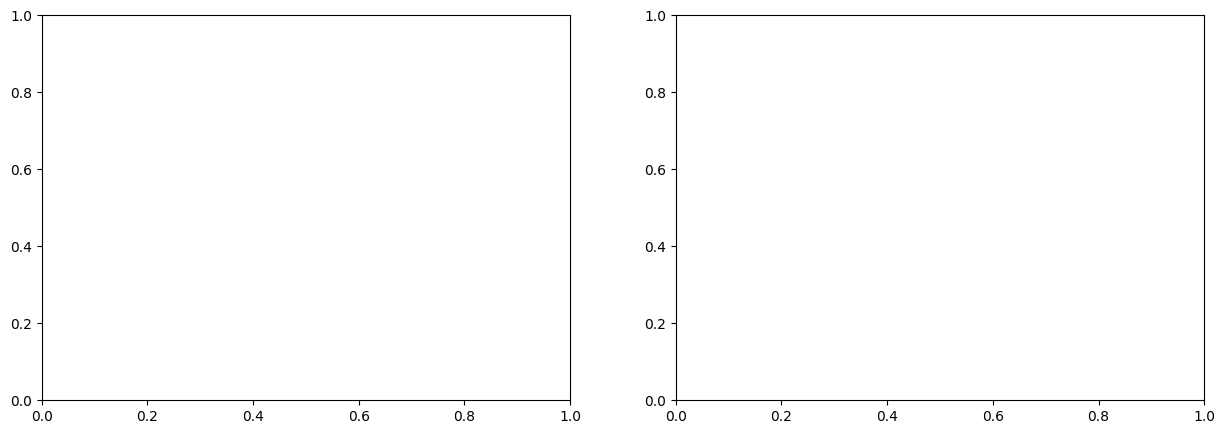

In [21]:
%matplotlib inline
# Plot dropped packets over distance and time
fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].hist(packet_stats_df['Distance'], weights=packet_stats_df['Dropped packet count'], bins=20)
ax[0].set_xlabel('Distance (m)')
ax[0].set_ylabel('Dropped packet count')
ax[1].hist(packet_stats_df['First seen at'], weights=packet_stats_df['Dropped packet count'], bins=20)
ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel('Dropped packet count')
plt.show()


In [ ]:
#matplotlib.use("TkAgg")
root = tkinter.Tk()

# Map 'Type' to colors
color_map = {'AP': 'red', 'STA': 'blue'}
colors = node_pos_df['NodeType'].map(color_map)

fig = plt.figure(dpi=100)

# Create four subplots
ax_node_pos = fig.add_subplot(221, projection='3d')
ax_dropped_packets = fig.add_subplot(222, projection='3d')
ax_latency = fig.add_subplot(223, projection='3d')
ax_signal = fig.add_subplot(224, projection='3d')

# Plot scatter on first subplot
ax_node_pos.scatter(node_pos_df['X'], node_pos_df['Y'], node_pos_df['Z'], c=colors)
ax_node_pos.set_title('Node positions')
ax_node_pos.set_xlabel('X (cartesian coord, m)')
ax_node_pos.set_ylabel('Y (cartesian coord, m)')
ax_node_pos.set_zlabel('Z (cartesian coord, m)')

# Plot bars on second subplot, where height is the dropped packet count
dropped_packets_colors = plt.cm.coolwarm(node_statistics_df['Dropped packet count'] / node_statistics_df['Dropped packet count'].max())
ax_dropped_packets.bar3d(node_statistics_df['X'], node_statistics_df['Y'], np.zeros(len(node_statistics_df)), .01, .01, node_statistics_df['Dropped packet count'], color=dropped_packets_colors)
ax_dropped_packets.set_title('Dropped packet count')
ax_dropped_packets.set_xlabel('X (cartesian coord, m)')
ax_dropped_packets.set_ylabel('Y (cartesian coord, m)')
ax_dropped_packets.set_zlabel('Dropped packet count')

# Plot bars on third subplot, where height is the average latency
latency_colors = plt.cm.coolwarm(node_statistics_df['Average latency'] / node_statistics_df['Average latency'].max())
ax_latency.bar3d(node_statistics_df['X'], node_statistics_df['Y'], np.zeros(len(node_statistics_df)), .01, .01, node_statistics_df['Average latency'], color=latency_colors)
ax_latency.set_title('Average latency')
ax_latency.set_xlabel('X (cartesian coord, m)')
ax_latency.set_ylabel('Y (cartesian coord, m)')
ax_latency.set_zlabel('Latency (ns)')

# Plot bars on fourth subplot, where height is the signal strength
signal_colors = plt.cm.coolwarm(node_statistics_df['Average signal strength'] / node_statistics_df['Average signal strength'].max())
ax_signal.bar3d(node_statistics_df['X'], node_statistics_df['Y'], np.zeros(len(node_statistics_df)), .01, .01, node_statistics_df['Average signal strength'], color=signal_colors)
ax_signal.set_title('Signal strength')
ax_signal.set_xlabel('X (cartesian coord, m)')
ax_signal.set_ylabel('Y (cartesian coord, m)')
ax_signal.set_zlabel('Signal strength (dB)')
# ax_signal.set_zlim(-100, -70)

# Sync the view limits
ax_node_pos.set_xlim(node_pos_df['X'].min(), node_pos_df['X'].max())
ax_node_pos.set_ylim(node_pos_df['Y'].min(), node_pos_df['Y'].max())
ax_dropped_packets.set_xlim(node_pos_df['X'].min(), node_pos_df['X'].max())
ax_dropped_packets.set_ylim(node_pos_df['Y'].min(), node_pos_df['Y'].max())
ax_latency.set_xlim(node_pos_df['X'].min(), node_pos_df['X'].max())
ax_latency.set_ylim(node_pos_df['Y'].min(), node_pos_df['Y'].max())

# Create canvas and toolbar
canvas = FigureCanvasTkAgg(fig, master=root)
canvas.draw()
toolbar = NavigationToolbar2Tk(canvas, root)
toolbar.update()
canvas.get_tk_widget().pack(side=tkinter.TOP, fill=tkinter.BOTH, expand=1)

# Function to sync rotation
def on_rotate(event):
    axes = [ax_node_pos, ax_dropped_packets, ax_latency, ax_signal]
    if event.inaxes in axes:
        # Get the current elevation and azimuth from the active axis
        elev = event.inaxes.elev
        azim = event.inaxes.azim
        
        # Update all other axes except the active one and unused one
        for ax in axes:
            if ax != event.inaxes:
                ax.view_init(elev=elev, azim=azim)
        
        fig.canvas.draw_idle()

fig.canvas.mpl_connect('motion_notify_event', on_rotate)

tkinter.mainloop()

TclError: no display name and no $DISPLAY environment variable